In [2]:
import os

# Path to your dataset
dataset_path = "/home/omtalmo/Olaf_TTK4265/Poles/rgb"
labels_dir = os.path.join(dataset_path, "labels")

### Aspect ratio analysis

/home/omtalmo/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Found 414 label files

=== Ground Truth Bounding Box Aspect Ratio Analysis ===
Total boxes analyzed: 505

Category distribution:
  very_tall: 505 boxes (100.0%) - AR range: 0.00 to 0.33

Statistical summary:
  Mean aspect ratio: 0.07
  Median aspect ratio: 0.07
  Standard deviation: 0.04
  Min aspect ratio: 0.02
  Max aspect ratio: 0.25


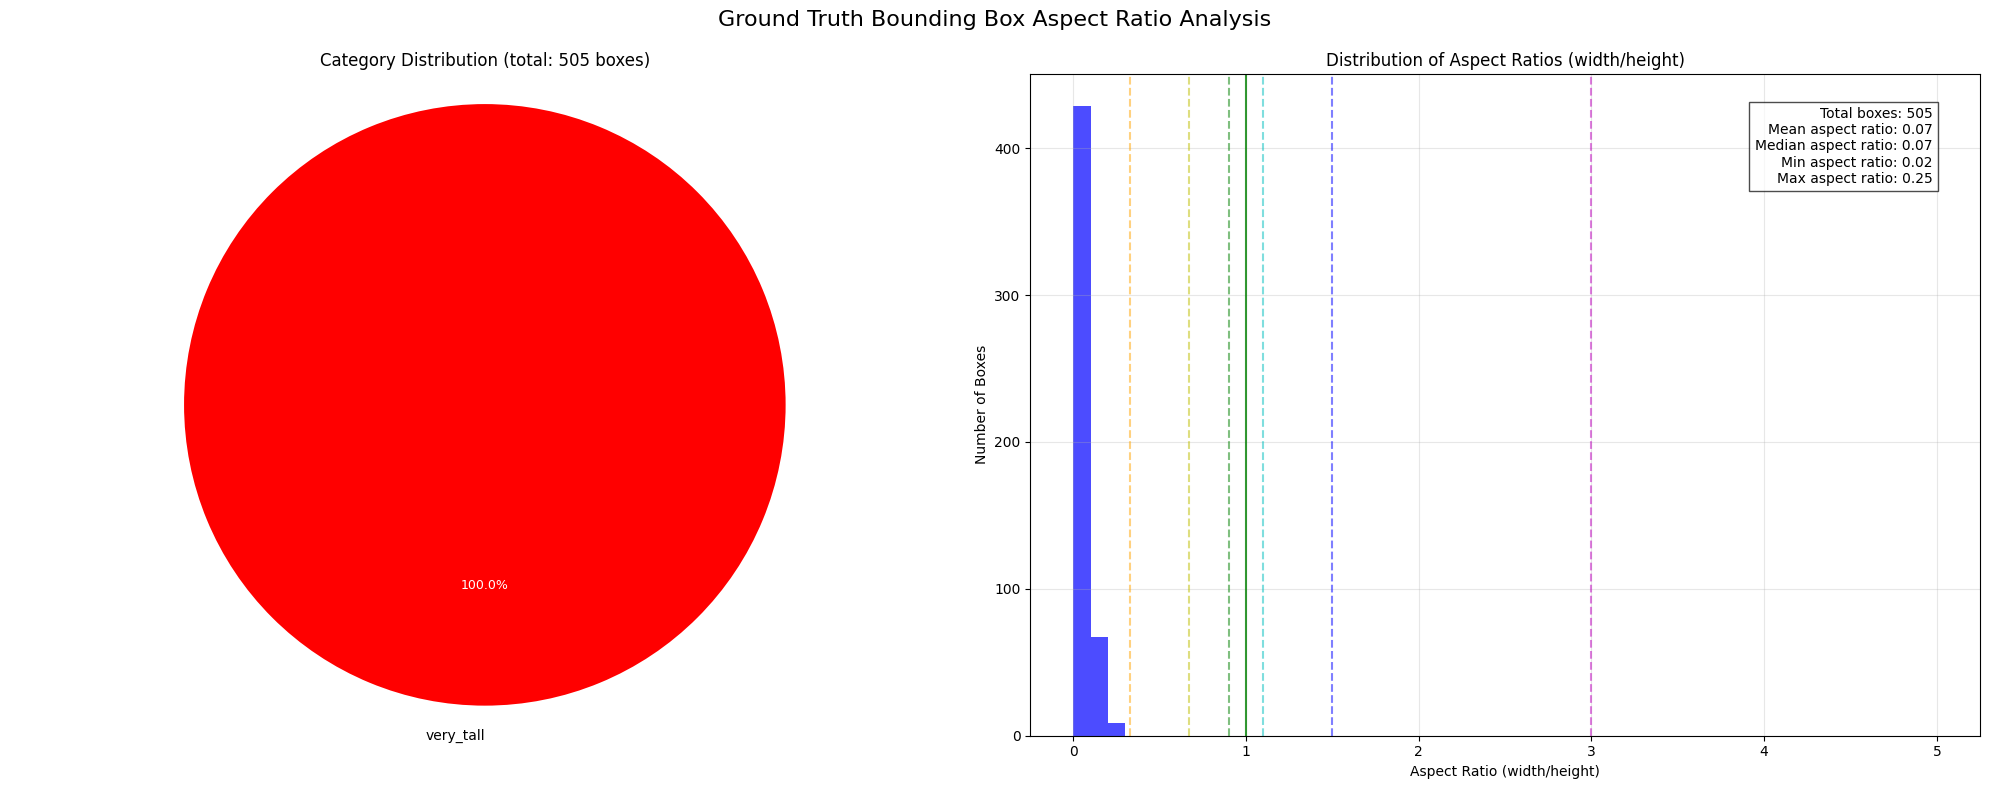

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict


def analyze_ground_truth_aspect_ratios():
    """
    Analyze aspect ratios of ground truth bounding boxes from label files.
    YOLO format labels: [class_id, x_center, y_center, width, height] (normalized)
    """
    # Collect all label files from train and valid directories
    all_label_files = []
    
    for split in ["train", "valid"]:
        split_dir = os.path.join(labels_dir, split)
        if os.path.exists(split_dir):
            label_files = [os.path.join(split_dir, f) for f in os.listdir(split_dir) if f.endswith('.txt')]
            all_label_files.extend(label_files)
    
    print(f"Found {len(all_label_files)} label files")
    
    # Extract aspect ratios from all files
    aspect_ratios = []
    
    for label_file in all_label_files:
        try:
            with open(label_file, 'r') as f:
                lines = f.readlines()
                
            for line in lines:
                parts = line.strip().split()
                if len(parts) == 5:  # YOLO format: class x_center y_center width height
                    # Extract normalized width and height
                    width = float(parts[3])
                    height = float(parts[4])
                    
                    if height > 0:  # Avoid division by zero
                        aspect_ratio = width / height
                        aspect_ratios.append(aspect_ratio)
        except Exception as e:
            print(f"Error processing {label_file}: {e}")
    
    # Define aspect ratio categories
    categories = {
        'very_tall': (0, 0.33),     # height is 3x+ width
        'tall': (0.33, 0.67),       # height is 1.5x to 3x width
        'slightly_tall': (0.67, 0.9), # height slightly larger than width
        'square': (0.9, 1.1),       # roughly square
        'slightly_wide': (1.1, 1.5), # width slightly larger than height
        'wide': (1.5, 3.0),        # width is 1.5x to 3x height
        'very_wide': (3.0, float('inf')) # width is 3x+ height
    }
    
    # Categorize boxes
    categorized = defaultdict(list)
    for ar in aspect_ratios:
        for category, (min_ar, max_ar) in categories.items():
            if min_ar <= ar < max_ar:
                categorized[category].append(ar)
                break
    
    # Count categories
    category_counts = {category: len(boxes) for category, boxes in categorized.items()}
    total_boxes = len(aspect_ratios)
    
    # Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(f"Ground Truth Bounding Box Aspect Ratio Analysis", fontsize=16)
    
    # 1. Pie chart of category distribution
    # Filter out categories with zero count
    non_empty_categories = {k: v for k, v in category_counts.items() if v > 0}
    
    if non_empty_categories:
        labels = non_empty_categories.keys()
        sizes = non_empty_categories.values()
        
        # Custom colors for each category
        colors = ['red', 'orangered', 'gold', 'green', 'cyan', 'blue', 'magenta']
        
        # Create pie chart
        patches, texts, autotexts = axes[0].pie(sizes, labels=labels, autopct='%1.1f%%',
                                                colors=colors, startangle=90)
        axes[0].axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
        
        # Make labels more readable
        for text in texts:
            text.set_fontsize(10)
        for autotext in autotexts:
            autotext.set_fontsize(9)
            autotext.set_color('white')
        
        axes[0].set_title(f"Category Distribution (total: {total_boxes} boxes)")
    else:
        axes[0].text(0.5, 0.5, "No boxes found", horizontalalignment='center',
                     verticalalignment='center', transform=axes[0].transAxes)
    
    # 2. Histogram of aspect ratios
    if aspect_ratios:
        axes[1].hist(aspect_ratios, bins=50, range=(0, 5), alpha=0.7, color='blue')
        axes[1].set_title(f"Distribution of Aspect Ratios (width/height)")
        axes[1].set_xlabel("Aspect Ratio (width/height)")
        axes[1].set_ylabel("Number of Boxes")
        axes[1].grid(alpha=0.3)
        
        # Add vertical lines for category boundaries
        colors = ['r', 'orange', 'y', 'g', 'c', 'b', 'm']
        for i, (category, (min_val, max_val)) in enumerate(categories.items()):
            if min_val > 0:
                axes[1].axvline(x=min_val, color=colors[i % len(colors)], linestyle='--', alpha=0.5)
        
        # Add vertical line at aspect ratio = 1 (square)
        axes[1].axvline(x=1.0, color='g', linestyle='-', alpha=0.8)
        
        # Add text showing statistics
        stats_text = "\n".join([
            f"Total boxes: {total_boxes}",
            f"Mean aspect ratio: {np.mean(aspect_ratios):.2f}",
            f"Median aspect ratio: {np.median(aspect_ratios):.2f}",
            f"Min aspect ratio: {min(aspect_ratios):.2f}",
            f"Max aspect ratio: {max(aspect_ratios):.2f}"
        ])
        axes[1].text(0.95, 0.95, stats_text, 
                   transform=axes[1].transAxes, 
                   fontsize=10, 
                   bbox=dict(facecolor='white', alpha=0.7),
                   verticalalignment='top', 
                   horizontalalignment='right')
    else:
        axes[1].text(0.5, 0.5, "No boxes found", horizontalalignment='center',
                     verticalalignment='center', transform=axes[1].transAxes)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    
    
    # Print summary statistics
    print("\n=== Ground Truth Bounding Box Aspect Ratio Analysis ===")
    print(f"Total boxes analyzed: {total_boxes}")
    print("\nCategory distribution:")
    for category, count in category_counts.items():
        percentage = (count / total_boxes * 100) if total_boxes > 0 else 0
        min_val, max_val = categories[category]
        print(f"  {category}: {count} boxes ({percentage:.1f}%) - AR range: {min_val:.2f} to {max_val:.2f}")
    
    if aspect_ratios:
        print("\nStatistical summary:")
        print(f"  Mean aspect ratio: {np.mean(aspect_ratios):.2f}")
        print(f"  Median aspect ratio: {np.median(aspect_ratios):.2f}")
        print(f"  Standard deviation: {np.std(aspect_ratios):.2f}")
        print(f"  Min aspect ratio: {min(aspect_ratios):.2f}")
        print(f"  Max aspect ratio: {max(aspect_ratios):.2f}")
    
    plt.show()
    
    return aspect_ratios, categorized, fig

# Run the analysis
aspect_ratios, categorized, fig = analyze_ground_truth_aspect_ratios()

### Height distribution

Found 414 label files

Total snow poles analyzed: 505
Maximum concentration at vertical position: 0.59 (where 0=top, 1=bottom)


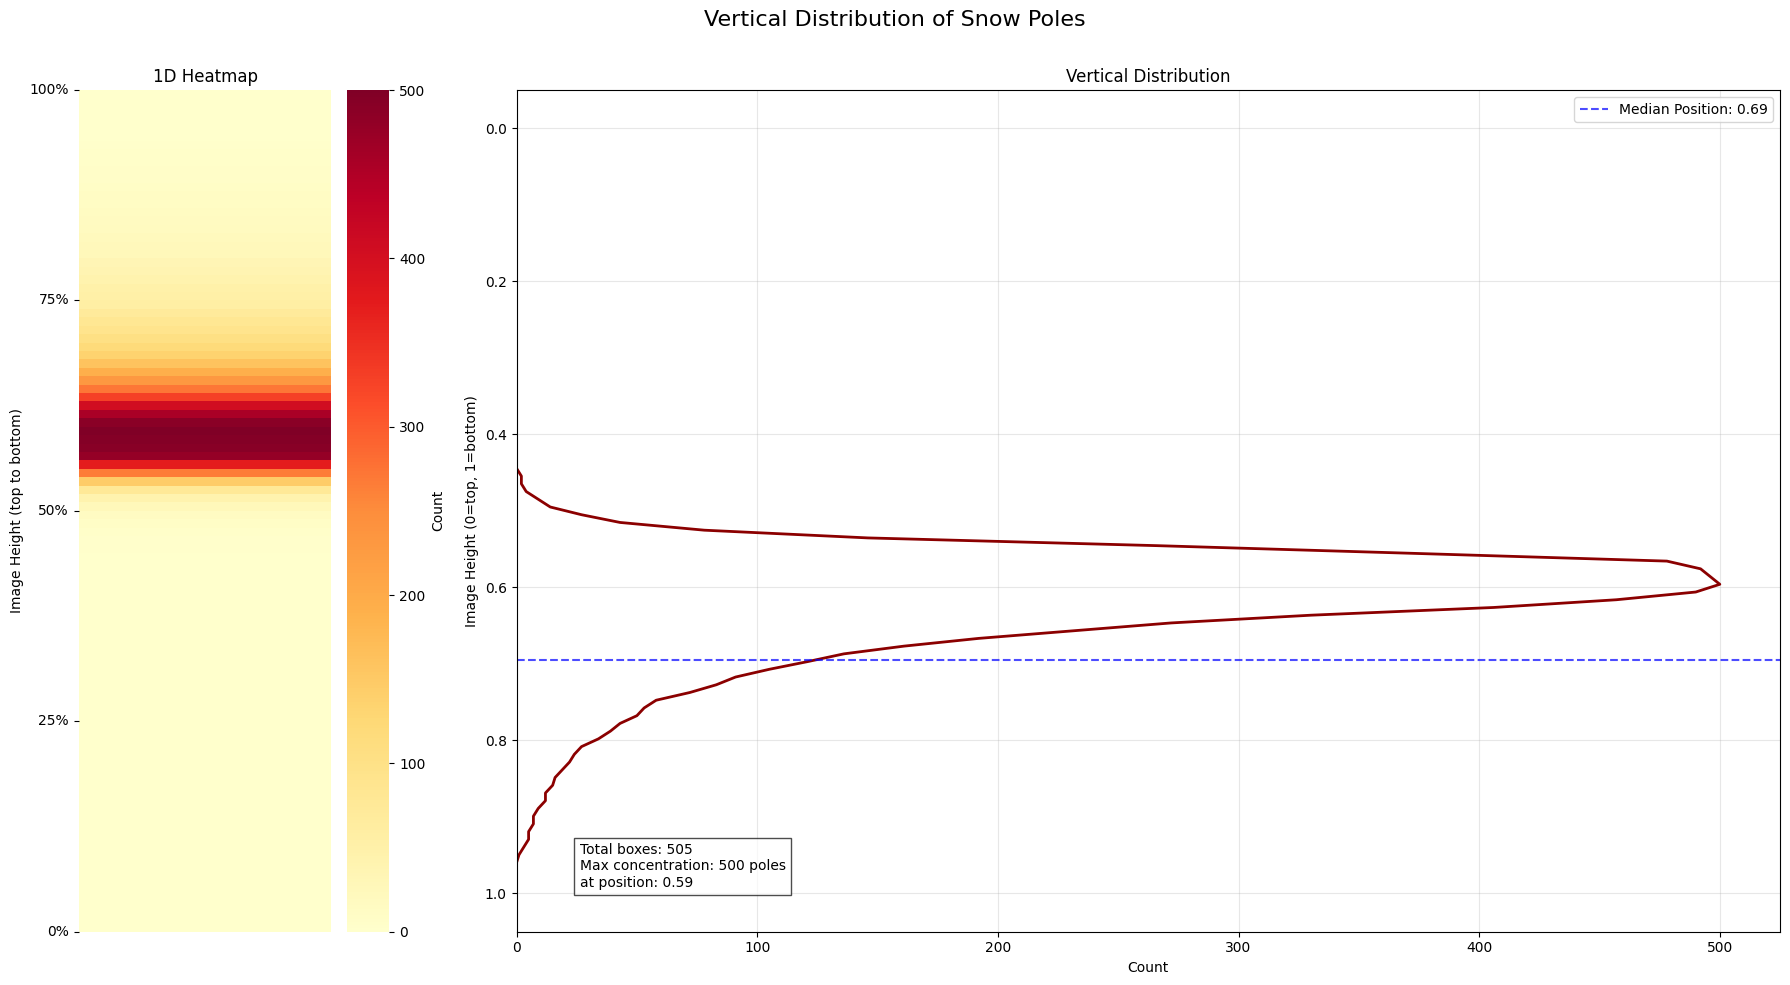

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict

def create_height_heatmap():
    """
    Create a 1D heatmap showing the vertical distribution of snow poles
    across the dataset based on ground truth labels.
    """
    # Parameters for the heatmap
    resolution = 100  # Number of vertical bins
    
    # Initialize the height density array
    height_density = np.zeros(resolution)
    
    # Collect all label files from train and valid directories
    all_label_files = []
    
    for split in ["train", "valid"]:
        split_dir = os.path.join(labels_dir, split)
        if os.path.exists(split_dir):
            label_files = [os.path.join(split_dir, f) for f in os.listdir(split_dir) if f.endswith('.txt')]
            all_label_files.extend(label_files)
    
    print(f"Found {len(all_label_files)} label files")
    
    # Extract height information from all files
    total_boxes = 0
    
    for label_file in all_label_files:
        try:
            with open(label_file, 'r') as f:
                lines = f.readlines()
                
            for line in lines:
                parts = line.strip().split()
                if len(parts) == 5:  # YOLO format: class x_center y_center width height
                    # Extract normalized y_center and height
                    y_center = float(parts[2])
                    height = float(parts[4])
                    
                    # Calculate the top and bottom y-coordinates (normalized)
                    y_top = y_center - (height / 2)
                    y_bottom = y_center + (height / 2)
                    
                    # Clamp values to [0, 1]
                    y_top = max(0, min(1, y_top))
                    y_bottom = max(0, min(1, y_bottom))
                    
                    # Add contribution to density array
                    # Map the range [y_top, y_bottom] to indices in height_density
                    top_idx = int(y_top * resolution)
                    bottom_idx = int(y_bottom * resolution)
                    
                    # Ensure valid indices
                    top_idx = max(0, min(resolution-1, top_idx))
                    bottom_idx = max(0, min(resolution-1, bottom_idx))
                    
                    # Increment counts for all vertical positions covered by this box
                    for i in range(top_idx, bottom_idx + 1):
                        height_density[i] += 1
                    
                    total_boxes += 1
        except Exception as e:
            print(f"Error processing {label_file}: {e}")
    
    # Create visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10), 
                                 gridspec_kw={'width_ratios': [1, 4]})
    fig.suptitle("Vertical Distribution of Snow Poles", fontsize=16)
    
    # Create 1D heatmap (vertical)
    # Reshape the 1D array to a 2D array for seaborn's heatmap
    height_density_2d = height_density.reshape(-1, 1)
    
    # First plot: 1D heatmap
    sns.heatmap(height_density_2d, ax=ax1, cmap="YlOrRd", 
                cbar_kws={'label': 'Count'})
    ax1.set_yticks([0, resolution/4, resolution/2, 3*resolution/4, resolution])
    ax1.set_yticklabels(['0%', '25%', '50%', '75%', '100%'])
    ax1.set_ylabel("Image Height (top to bottom)")
    ax1.set_xticks([])
    ax1.set_title("1D Heatmap")
    
    # Add more detailed plot showing distribution
    ax2.plot(height_density, np.linspace(0, 1, resolution), 
             color='darkred', linewidth=2)
    ax2.set_xlabel("Count")
    ax2.set_ylabel("Image Height (0=top, 1=bottom)")
    ax2.set_title("Vertical Distribution")
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(left=0)
    
    # Add a horizontal line at the median position
    nonzero_indices = np.nonzero(height_density)[0]
    if len(nonzero_indices) > 0:
        median_idx = np.median(nonzero_indices)
        median_pos = median_idx / resolution
        ax2.axhline(y=median_pos, color='blue', linestyle='--', alpha=0.7,
                   label=f'Median Position: {median_pos:.2f}')
        ax2.legend()
    
    # Add text with statistics
    max_count = height_density.max()
    max_position = np.argmax(height_density) / resolution
    
    stats_text = "\n".join([
        f"Total boxes: {total_boxes}",
        f"Max concentration: {max_count:.0f} poles",
        f"at position: {max_position:.2f}"
    ])
    
    ax2.text(0.05, 0.05, stats_text, 
             transform=ax2.transAxes, 
             fontsize=10, 
             bbox=dict(facecolor='white', alpha=0.7),
             verticalalignment='bottom')
    
    # Invert both y-axes so 0 is at top (like in an image)
    ax1.invert_yaxis()
    ax2.invert_yaxis()
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    
    print(f"\nTotal snow poles analyzed: {total_boxes}")
    print(f"Maximum concentration at vertical position: {max_position:.2f} (where 0=top, 1=bottom)")
    
    return height_density, fig

# Run the analysis
height_density, fig = create_height_heatmap()
plt.show()

### Analyze relation between box height and y-position in image

Found 414 label files

=== Box Height vs. Bottom Position Analysis ===
Total boxes analyzed: 505

Statistical summary:
  Mean box height: 0.1198
  Median box height: 0.0941

Regression models:
  Linear model: height = 1.0651 × (bottom_position) + -0.5903
  Linear model R²: 0.9196
  Polynomial model (degree 2): height = 1.0016 × (bottom_position)² + -0.3906 × (bottom_position) + -0.0693
  Polynomial model R²: 0.9270

Relationship interpretation:
  Boxes tend to be 1.07 times taller as they move toward the bottom of the image.
  The linear model is sufficient to describe this relationship.


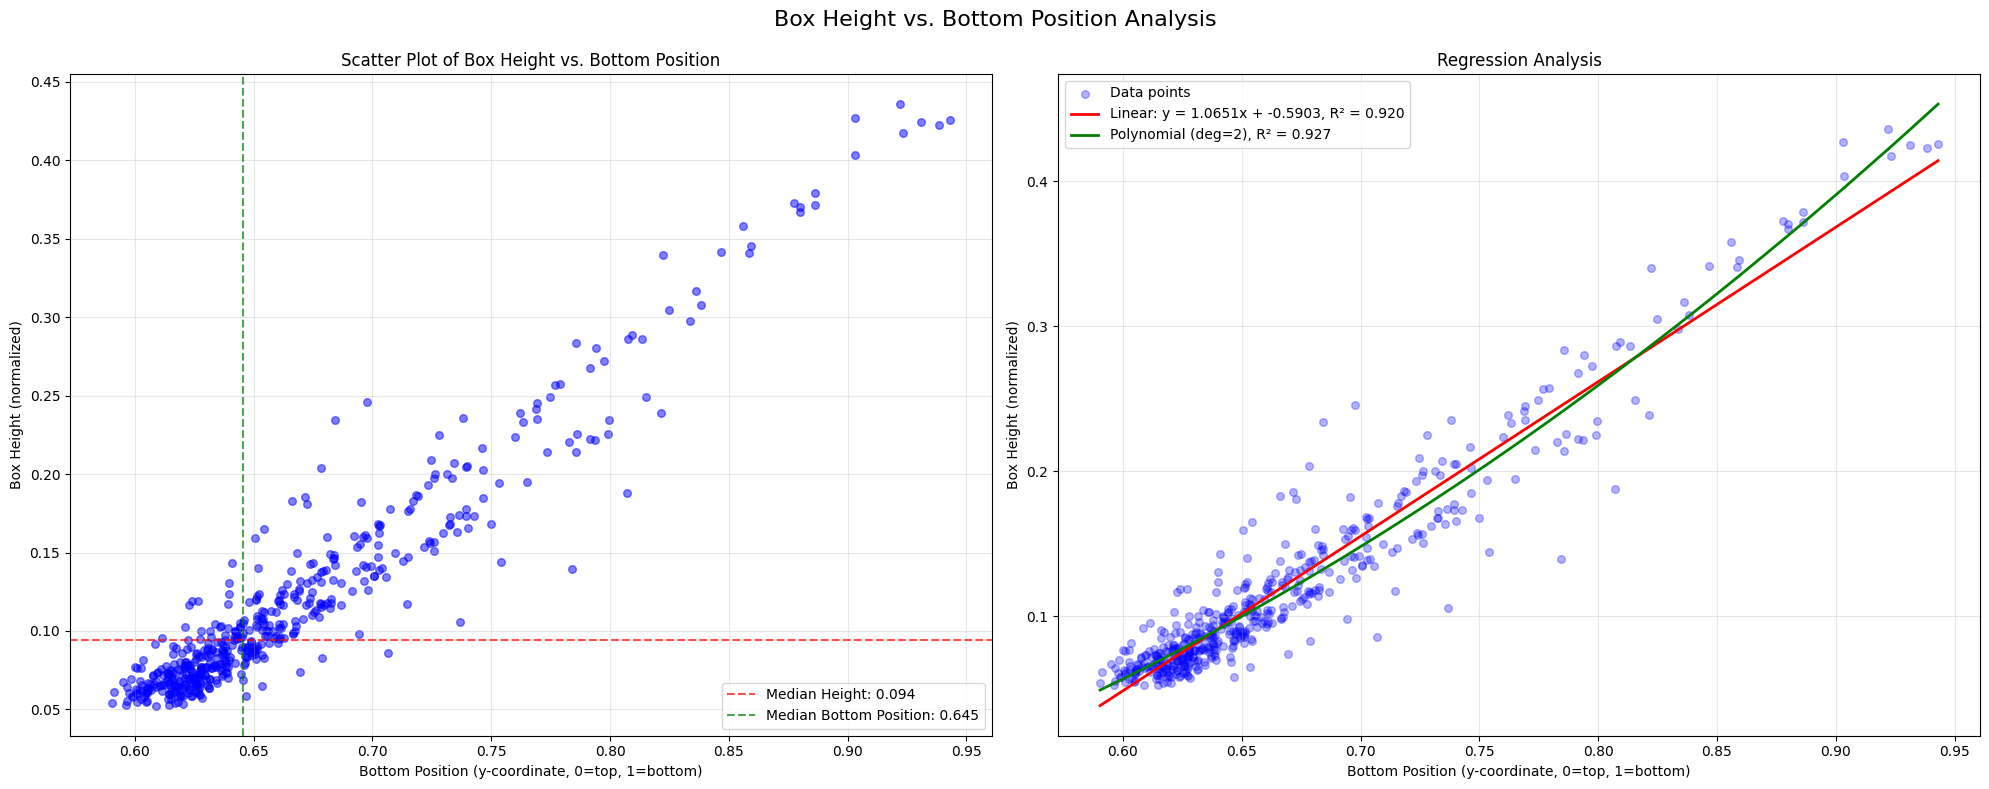

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

def analyze_box_height_vs_position():
    """
    Analyze the relationship between box height and its vertical position in the image.
    Creates a scatter plot where:
    - x-axis: y-position of the bottom edge of the box (normalized)
    - y-axis: height of the box (normalized)
    """
    # Collect all label files
    all_label_files = []
    
    for split in ["train", "valid"]:
        split_dir = os.path.join(labels_dir, split)
        if os.path.exists(split_dir):
            label_files = [os.path.join(split_dir, f) for f in os.listdir(split_dir) if f.endswith('.txt')]
            all_label_files.extend(label_files)
    
    print(f"Found {len(all_label_files)} label files")
    
    # Extract height and position data
    box_heights = []
    bottom_positions = []
    
    for label_file in all_label_files:
        try:
            with open(label_file, 'r') as f:
                lines = f.readlines()
                
            for line in lines:
                parts = line.strip().split()
                if len(parts) == 5:  # YOLO format: class x_center y_center width height
                    # Extract normalized y_center and height
                    y_center = float(parts[2])
                    height = float(parts[4])
                    
                    # Calculate bottom y-coordinate (normalized)
                    y_bottom = y_center + (height / 2)
                    
                    # Keep values within [0, 1]
                    y_bottom = min(1.0, max(0.0, y_bottom))
                    
                    # Store data
                    box_heights.append(height)
                    bottom_positions.append(y_bottom)
        except Exception as e:
            print(f"Error processing {label_file}: {e}")
    
    # Create figure for visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle("Box Height vs. Bottom Position Analysis", fontsize=16)
    
    # Plot 1: Simple scatter plot
    ax1.scatter(bottom_positions, box_heights, alpha=0.5, s=30, c='blue')
    ax1.set_xlabel("Bottom Position (y-coordinate, 0=top, 1=bottom)")
    ax1.set_ylabel("Box Height (normalized)")
    ax1.set_title("Scatter Plot of Box Height vs. Bottom Position")
    ax1.grid(True, alpha=0.3)
    
    # Add median lines
    ax1.axhline(y=np.median(box_heights), color='red', linestyle='--', alpha=0.7,
               label=f'Median Height: {np.median(box_heights):.3f}')
    ax1.axvline(x=np.median(bottom_positions), color='green', linestyle='--', alpha=0.7,
               label=f'Median Bottom Position: {np.median(bottom_positions):.3f}')
    ax1.legend()
    
    # Plot 2: Scatter with regression models
    ax2.scatter(bottom_positions, box_heights, alpha=0.3, s=30, c='blue', label='Data points')
    ax2.set_xlabel("Bottom Position (y-coordinate, 0=top, 1=bottom)")
    ax2.set_ylabel("Box Height (normalized)")
    ax2.set_title("Regression Analysis")
    ax2.grid(True, alpha=0.3)
    
    # Prepare data for regression
    X = np.array(bottom_positions).reshape(-1, 1)
    y = np.array(box_heights)
    
    # Linear regression
    linear_model = LinearRegression()
    linear_model.fit(X, y)
    y_linear_pred = linear_model.predict(X)
    linear_r2 = r2_score(y, y_linear_pred)
    
    # Polynomial regression (degree 2)
    poly2_model = make_pipeline(PolynomialFeatures(2), LinearRegression())
    poly2_model.fit(X, y)
    y_poly2_pred = poly2_model.predict(X)
    poly2_r2 = r2_score(y, y_poly2_pred)
    
    # Sort for line plotting
    sorted_indices = np.argsort(X.flatten())
    X_sorted = X.flatten()[sorted_indices]
    y_linear_sorted = y_linear_pred[sorted_indices]
    y_poly2_sorted = y_poly2_pred[sorted_indices]
    
    # Plot regression lines
    ax2.plot(X_sorted, y_linear_sorted, 'r-', linewidth=2, 
             label=f'Linear: y = {linear_model.coef_[0]:.4f}x + {linear_model.intercept_:.4f}, R² = {linear_r2:.3f}')
    ax2.plot(X_sorted, y_poly2_sorted, 'g-', linewidth=2, 
             label=f'Polynomial (deg=2), R² = {poly2_r2:.3f}')
    ax2.legend()
    
    # Print analysis results
    print("\n=== Box Height vs. Bottom Position Analysis ===")
    print(f"Total boxes analyzed: {len(box_heights)}")
    print("\nStatistical summary:")
    print(f"  Mean box height: {np.mean(box_heights):.4f}")
    print(f"  Median box height: {np.median(box_heights):.4f}")
    
    print("\nRegression models:")
    print(f"  Linear model: height = {linear_model.coef_[0]:.4f} × (bottom_position) + {linear_model.intercept_:.4f}")
    print(f"  Linear model R²: {linear_r2:.4f}")
    
    # Extract polynomial coefficients
    poly_coeffs = poly2_model.named_steps['linearregression'].coef_
    poly_intercept = poly2_model.named_steps['linearregression'].intercept_
    
    # Print polynomial formula in readable format
    print(f"  Polynomial model (degree 2): height = {poly_coeffs[2]:.4f} × (bottom_position)² + {poly_coeffs[1]:.4f} × (bottom_position) + {poly_intercept:.4f}")
    print(f"  Polynomial model R²: {poly2_r2:.4f}")
    
    # Add slope analysis
    print("\nRelationship interpretation:")
    if abs(linear_model.coef_[0]) < 0.1:
        print("  The data shows minimal correlation between box height and position.")
    elif linear_model.coef_[0] > 0:
        print(f"  Boxes tend to be {abs(linear_model.coef_[0]):.2f} times taller as they move toward the bottom of the image.")
    else:
        print(f"  Boxes tend to be {abs(linear_model.coef_[0]):.2f} times shorter as they move toward the bottom of the image.")
    
    # Print which model fits better
    if poly2_r2 > linear_r2 + 0.05:  # Only recommend polynomial if it's significantly better
        print("  The polynomial model provides a better fit for this relationship.")
    else:
        print("  The linear model is sufficient to describe this relationship.")
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    
    return box_heights, bottom_positions, fig

# Run the analysis
box_heights, bottom_positions, fig = analyze_box_height_vs_position()
plt.show()